In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/pepperfry_dataset.csv')

In [ ]:
df.head()

,Order_ID,Order_Date,Customer_ID,City,State,Product_Category,Product_Name,Price,Quantity,Discount,Revenue,Payment_Method,Delivery_Status,Customer_Rating,Warehouse,Shipping_Days
0,ORD100000,2025-04-21,CUST3909,Mumbai,Maharashtra,Table,Coffee Table,41896,3,0.08,115632.96,Credit Card,Shipped,4,WH-BLR,9
1,ORD100001,2024-02-19,CUST5627,Delhi,Delhi,Chair,Recliner Chair,27076,5,0.20,108304.00,Debit Card,Processing,1,WH-BLR,10
2,ORD100002,2024-10-06,CUST5364,Mumbai,Maharashtra,Bookshelf,Wall Bookshelf,19412,5,0.16,81530.40,Credit Card,Shipped,3,WH-MUM,3
3,ORD100003,2025-04-18,CUST8689,Mumbai,Maharashtra,Dining Set,6 Seater Dining,22618,4,0.09,82329.52,Net Banking,Shipped,4,WH-HYD,5
4,ORD100004,2025-04-26,CUST2198,Kolkata,West Bengal,Table,Coffee Table,26578,3,0.01,78936.66,Debit Card,Shipped,4,WH-BLR,9


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
City,0
State,0
Product_Category,0
Product_Name,0
Price,0
Quantity,0
Discount,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  object 
 1   Order_Date        10000 non-null  object 
 2   Customer_ID       10000 non-null  object 
 3   City              10000 non-null  object 
 4   State             10000 non-null  object 
 5   Product_Category  10000 non-null  object 
 6   Product_Name      10000 non-null  object 
 7   Price             10000 non-null  int64  
 8   Quantity          10000 non-null  int64  
 9   Discount          10000 non-null  float64
 10  Revenue           10000 non-null  float64
 11  Payment_Method    10000 non-null  object 
 12  Delivery_Status   10000 non-null  object 
 13  Customer_Rating   10000 non-null  int64  
 14  Warehouse         10000 non-null  object 
 15  Shipping_Days     10000 non-null  int64  
dtypes: float64(2), int64(4), object(10)
memor

In [ ]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'City', 'State',
       'Product_Category', 'Product_Name', 'Price', 'Quantity', 'Discount',
       'Revenue', 'Payment_Method', 'Delivery_Status', 'Customer_Rating',
       'Warehouse', 'Shipping_Days'],
      dtype='object')

<Axes: ylabel='Quantity'>

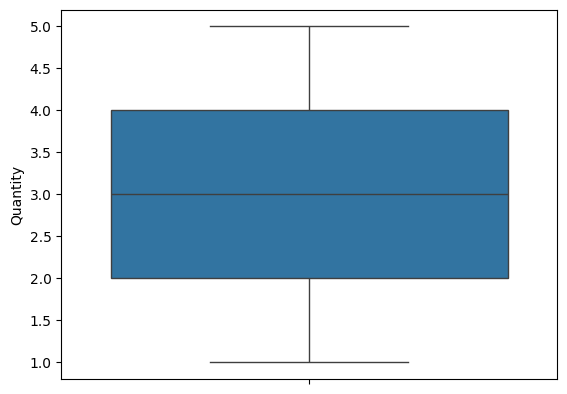

In [ ]:
sns.boxplot(df['Quantity'])

<Axes: ylabel='Discount'>

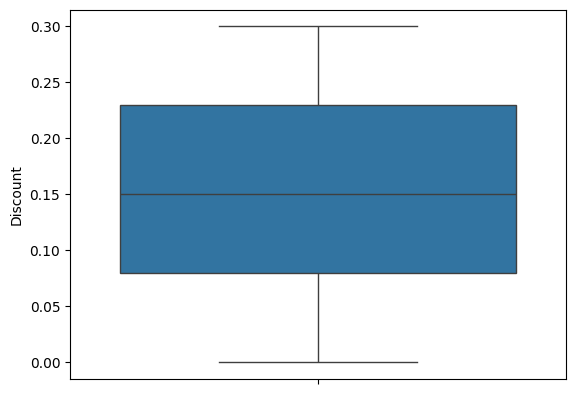

In [ ]:
sns.boxplot(df['Discount'])

<Axes: ylabel='Price'>

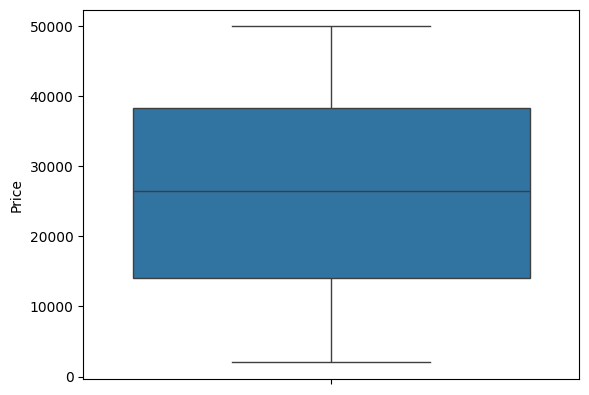

In [ ]:
sns.boxplot(df['Price'])

In [ ]:
x = df[['Price','Quantity','Discount']]

In [ ]:
y = df['Revenue']

In [ ]:
corr = df[['Price','Quantity','Discount','Customer_Rating','Revenue']]

<Axes: >

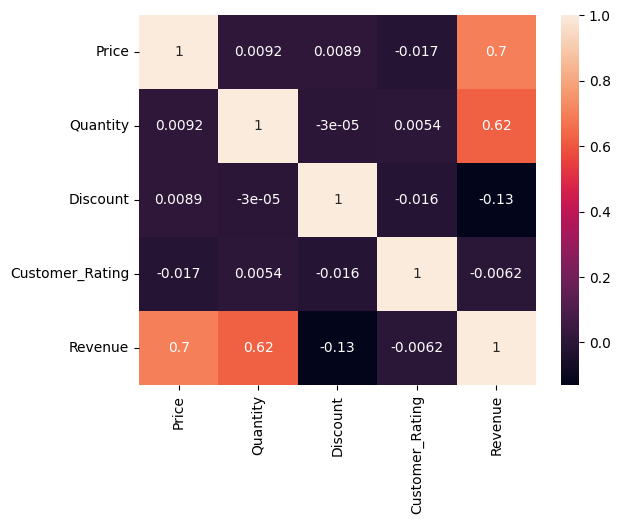

In [ ]:
sns.heatmap(corr.corr(),annot=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 2. Initialize the model
lr = LinearRegression()

# 3. Fit (train) the model on the training data
lr.fit(X_train, y_train)

# 4. Make predictions on the testing data
y_pred = lr.predict(X_test)

# 5. Calculate the evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error",mse)
print("R-squared",r2)

Mean Squared Error 313608558.8694217
R-squared 0.8837080407485151


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize the Decision Tree model
# Using a random_state ensures your results are reproducible
dt = DecisionTreeRegressor(max_depth=5,random_state=42)

# 2. Fit (train) the model using the data you split earlier
dt.fit(X_train, y_train)

# 3. Make predictions on the testing data
y_pred_dt = dt.predict(X_test)

# 4. Calculate the evaluation metrics
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Mean Squared Error:",mse_dt)
print("Decision Tree R-squared:",r2_dt)


Decision Tree Mean Squared Error: 126258778.94655676
Decision Tree R-squared: 0.9531808671634221


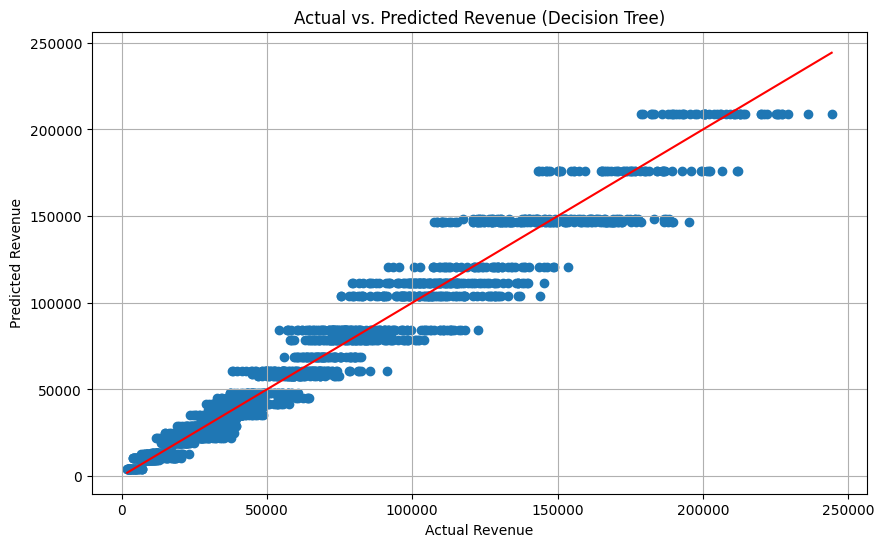

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test,y_pred_dt)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],color='red'),
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs. Predicted Revenue (Decision Tree)")
plt.grid(True)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest Mean Squared Error:",mse_rf)
print("Random Forest R-squared:",r2_rf)
print("Random Forest Mean Absolute Error:",mae_rf)

Random Forest Mean Squared Error: 500202.0591310464
Random Forest R-squared: 0.9998145156570737
Random Forest Mean Absolute Error: 459.5102016999989


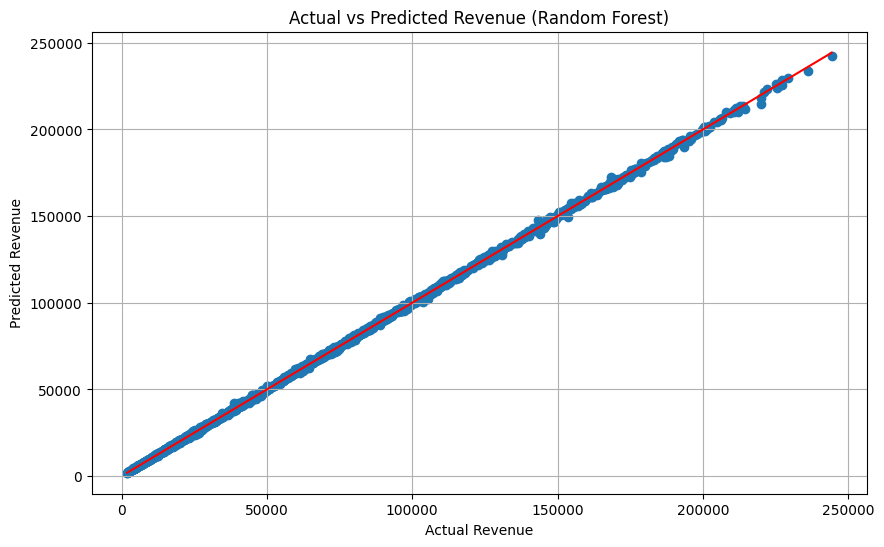

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test,y_pred_rf)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],color='red'),
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue (Random Forest)")
plt.grid(True)